# SLR Diagnostics — Root Cause Analysis

| Question | Where |
|---|---|
| Is the model accurate on the dataset? | Cell 4 — Accuracy / F1 |
| Which letters are failing? | Cell 5 — Per-class bar chart |
| Which letters confuse each other? | Cell 6 — Confusion matrix |
| Is threshold 0.75 too strict? | Cell 7 — Confidence + threshold sweep |
| Is the problem the live camera vs dataset? | Cell 11 — Live probability viewer |


## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, mediapipe as mp, time, os, threading, queue
from collections import deque
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, top_k_accuracy_score
)
plt.rcParams["figure.dpi"] = 110
print("✓ Imports OK")

✓ Imports OK


## 1. Select Language

Set `LANGUAGE = "english"` or `"arabic"`.


In [2]:
LANGUAGE = "english"   # <── change to "arabic" for ArSL

if LANGUAGE == "english":
    MODEL_PATH   = r"asl_mediapipe_mlp_model.h5"
    DATASET_PATH = r"asl_mediapipe_keypoints_dataset.csv"
    CLASS_LABELS = [
        "A","B","C","D","E","F","G","H",
        "I","J","K","L","M","N","O","P",
        "Q","R","S","T","U","V","W","X",
        "Y","Z","del","nothing","space"
    ]
    TITLE_PREFIX = "ASL (English)"
else:
    MODEL_PATH   = r"arsl_mediapipe_mlp_model_final.h5"
    DATASET_PATH = r"FINAL_CLEAN_DATASET.csv"
    CLASS_LABELS = [
        "ا","ب","ت","ث","ج","ح","خ","د","ذ","ر",
        "ز","س","ش","ص","ض","ط","ظ","ع","غ","ف",
        "ق","ك","ل","م","ن","ه","و","ي",
        "space","del","nothing"
    ]
    TITLE_PREFIX = "ArSL (Arabic)"

print(f"Language : {LANGUAGE.upper()}")
print(f"Model    : {MODEL_PATH}")
print(f"Dataset  : {DATASET_PATH}")
print(f"Classes  : {len(CLASS_LABELS)}")

Language : ENGLISH
Model    : asl_mediapipe_mlp_model.h5
Dataset  : asl_mediapipe_keypoints_dataset.csv
Classes  : 29


## 2. Load Model

In [3]:
model = tf.keras.models.load_model(MODEL_PATH)
model.summary()
print("\n✓ Model loaded")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               8192      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 28)                1820      
                                                                 
Total params: 18,268
Trainable params: 18,268
Non-trainable params: 0
_________________________________________________________________

✓ Model loaded


## 3. Load & Prepare Dataset

Uses the same 80/20 stratified split (random_state=42) as the training notebooks.


In [4]:
df = pd.read_csv(DATASET_PATH)
print(f"Shape: {df.shape}")
label_col = df.columns[-1]
X = df.drop(columns=[label_col]).values.astype(np.float32)
y_raw = df[label_col].values

le = LabelEncoder()
le.classes_ = np.array(CLASS_LABELS)
try:
    y_enc = le.transform(y_raw)
except ValueError as e:
    print(f"⚠ Label mismatch: {e}")
    print("In dataset but not in CLASS_LABELS:", set(y_raw) - set(CLASS_LABELS))
    raise

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print("✓ Dataset ready")

Shape: (59801, 64)
Train: 47,840  |  Test: 11,961
✓ Dataset ready


## 4. Run Full Evaluation

In [5]:
probs     = model.predict(X_test, batch_size=512, verbose=1)
y_pred    = np.argmax(probs, axis=1)
y_conf    = np.max(probs,   axis=1)

acc1 = accuracy_score(y_test, y_pred)
acc2 = top_k_accuracy_score(y_test, probs, k=2)
acc3 = top_k_accuracy_score(y_test, probs, k=3)

print("=" * 52)
print(f"  Top-1 Accuracy : {acc1*100:.2f}%")
print(f"  Top-2 Accuracy : {acc2*100:.2f}%")
print(f"  Top-3 Accuracy : {acc3*100:.2f}%")
print("=" * 52)
print(classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=3))
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, target_names=CLASS_LABELS, digits=3, output_dict=True)
).T
print("✓ Evaluation complete")

24/24 [==============================] - 4s 4ms/step
  Top-1 Accuracy : 90.69%
  Top-2 Accuracy : 98.88%
  Top-3 Accuracy : 99.31%
              precision    recall  f1-score   support

           A      0.986     0.990     0.988       417
           B      0.977     1.000     0.989       430
           C      0.994     0.992     0.993       359
           D      0.993     0.974     0.984       460
           E      0.963     1.000     0.981       440
           F      0.998     0.958     0.978       554
           G      1.000     0.959     0.979       458
           H      0.989     0.972     0.980       460
           I      0.917     0.974     0.944       454
           J      1.000     0.922     0.959       487
           K      1.000     0.965     0.982       520
           L      1.000     0.996     0.998       484
           M      0.675     0.920     0.779       237
           N      0.822     0.558     0.665       199
           O      0.919     1.000     0.958       432
    

c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HADEEL GAMALELDIN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control th

## 5. Per-Class F1 / Precision / Recall

**Red dashed line = 0.80.** Any bar below this is a problem class.
- Low recall → model misses the sign (predicts something else)
- Low precision → model fires this label when it should be something else


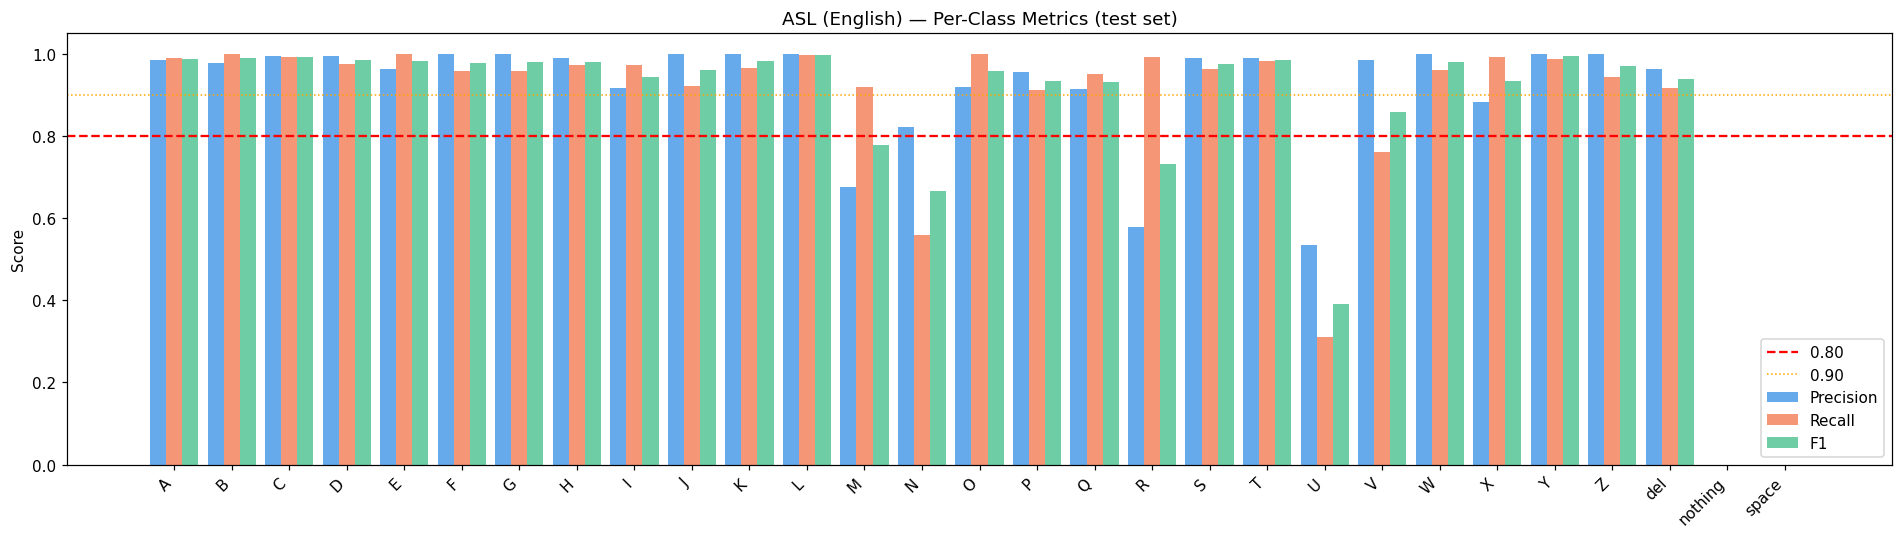


⚠ Lowest F1 classes:
  nothing  F1=0.000  P=0.000  R=0.000
  space   F1=0.000  P=0.000  R=0.000
  U       F1=0.392  P=0.533  R=0.310
  N       F1=0.665  P=0.822  R=0.558
  R       F1=0.731  P=0.579  R=0.992


In [7]:
per_class = report_df.loc[CLASS_LABELS][["precision","recall","f1-score"]].astype(float)

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 5))
x = np.arange(len(CLASS_LABELS)); w = 0.28
ax.bar(x-w, per_class["precision"], w, label="Precision", color="#4C9BE8", alpha=0.85)
ax.bar(x,   per_class["recall"],    w, label="Recall",    color="#F4845F", alpha=0.85)
ax.bar(x+w, per_class["f1-score"],  w, label="F1",        color="#56C596", alpha=0.85)
ax.axhline(0.80, color="red",    linestyle="--", lw=1.5, label="0.80")
ax.axhline(0.90, color="orange", linestyle=":",  lw=1.0, label="0.90")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_LABELS, rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score")
ax.set_title(f"{TITLE_PREFIX} — Per-Class Metrics (test set)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

worst = per_class["f1-score"].nsmallest(5)
print("\n⚠ Lowest F1 classes:")
for cls, val in worst.items():
   print(f"  {cls:<6}  F1={val:.3f}  P={per_class.loc[cls,'precision']:.3f}  R={per_class.loc[cls,'recall']:.3f}")

## 6. Confusion Matrix

Diagonal suppressed so errors are visible. Off-diagonal bright cells = pairs that confuse each other.


C:\Users\HADEEL GAMALELDIN\AppData\Local\Temp\ipykernel_14776\892818720.py:2: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


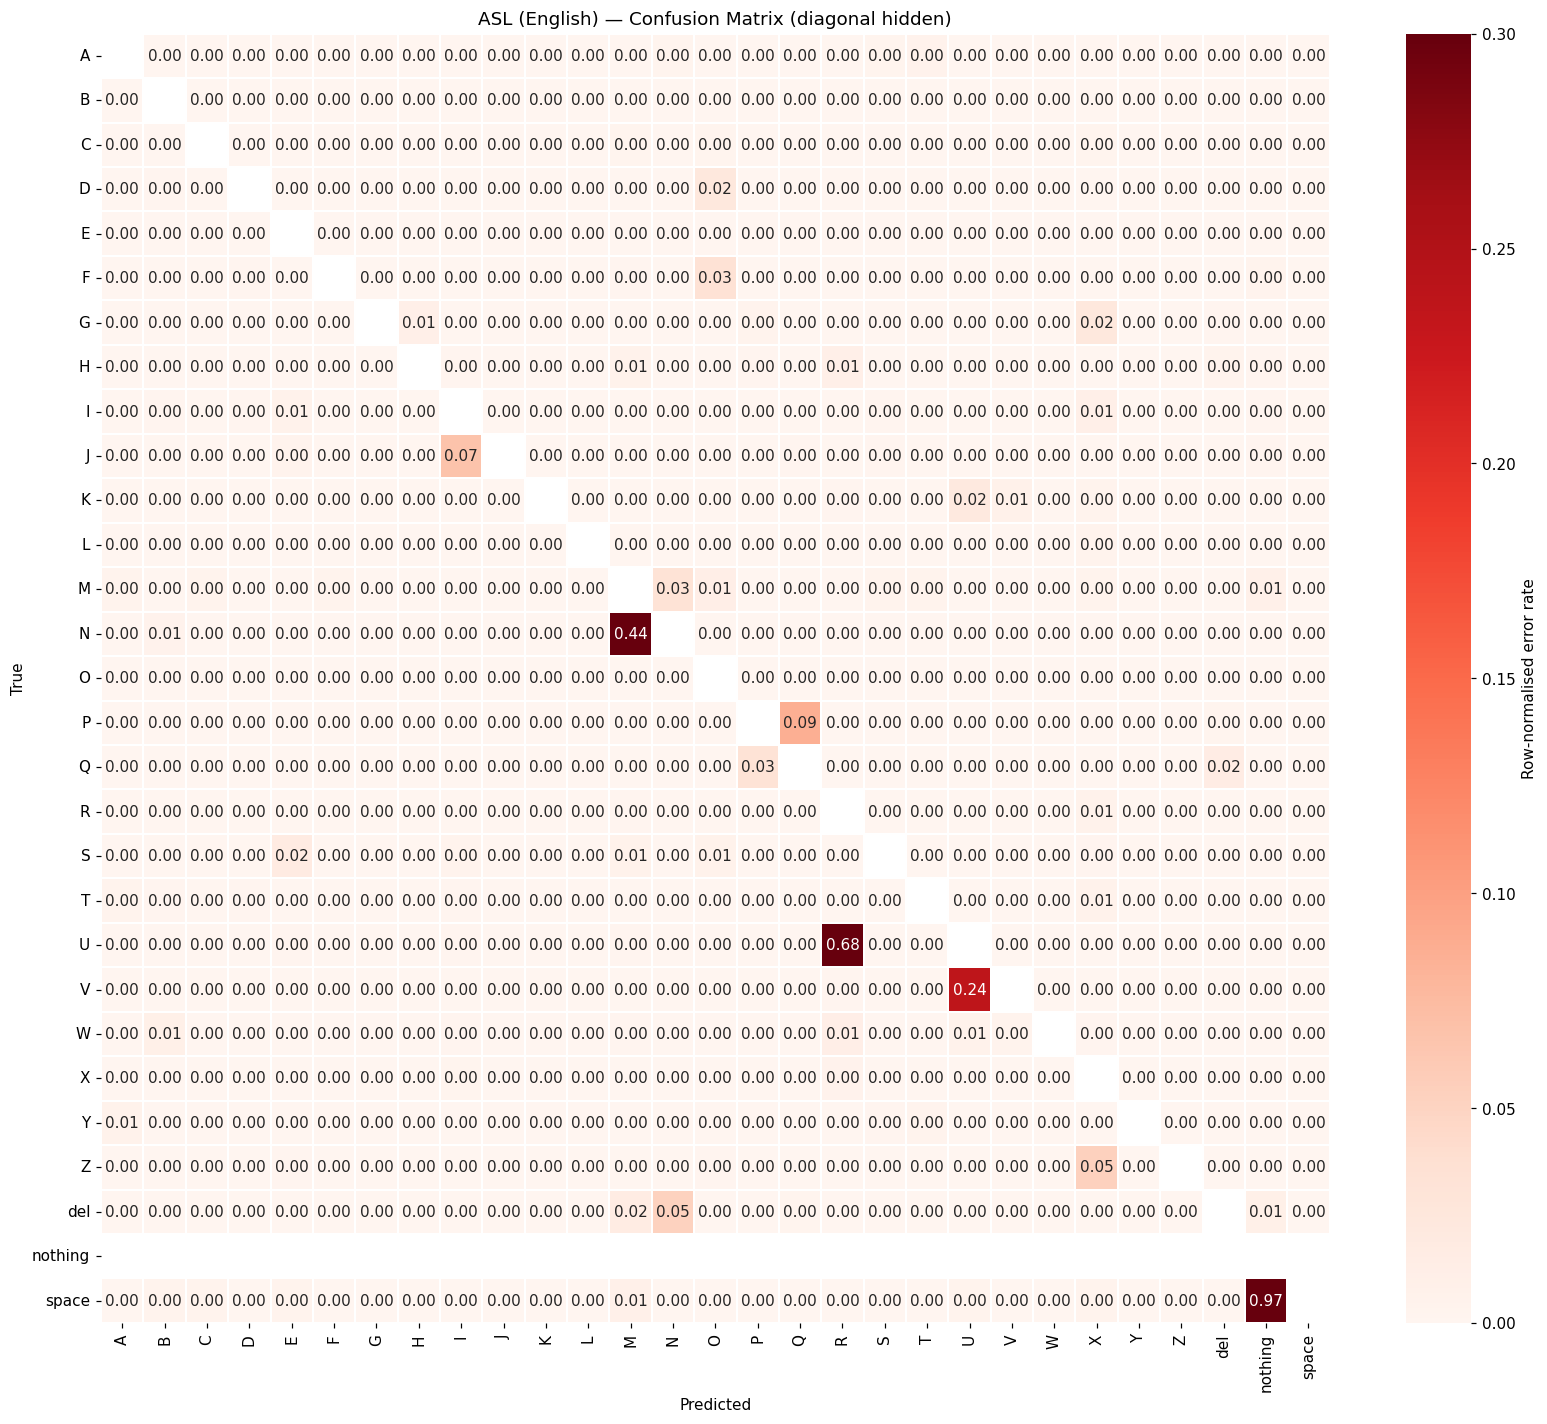


🔥 Top-10 confused pairs (True → Predicted):
  space  → nothing  97.1%
  U      → R       68.4%
  N      → M       43.7%
  V      → U       23.7%
  P      → Q       8.6%
  J      → I       6.8%
  Z      → X       5.3%
  del    → N       5.3%
  F      → O       3.4%
  M      → N       3.4%


In [8]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
n       = len(CLASS_LABELS)

fig, ax = plt.subplots(figsize=(max(14, n*0.52), max(11, n*0.45)))
mask    = np.eye(n, dtype=bool)
sns.heatmap(cm_norm, annot=(n<=32), fmt=".2f", cmap="Reds",
            linewidths=0.3, xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=ax, mask=mask, vmin=0, vmax=0.3,
            cbar_kws={"label":"Row-normalised error rate"})
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"{TITLE_PREFIX} — Confusion Matrix (diagonal hidden)")
plt.tight_layout(); plt.show()

cm_nd = cm_norm.copy(); np.fill_diagonal(cm_nd, 0)
pairs = [(CLASS_LABELS[i], CLASS_LABELS[j], cm_nd[i,j])
         for i in range(n) for j in range(n) if i!=j and cm_nd[i,j]>0]
pairs.sort(key=lambda x: -x[2])
print("\n🔥 Top-10 confused pairs (True → Predicted):")
for t,p,r in pairs[:10]:
    print(f"  {t:<6} → {p:<6}  {r*100:.1f}%")

## 7. Confidence Distribution & Threshold Sweep

**Left plot:** green = correct predictions, red = incorrect — see where they overlap.
**Right plot:** sweep the threshold and read off the coverage/precision trade-off.

- Histogram peaked near 1.0 → model is confident; threshold is fine → problem is camera/lighting
- Long tail below 0.75 → threshold is filtering valid preds → lower it OR retrain


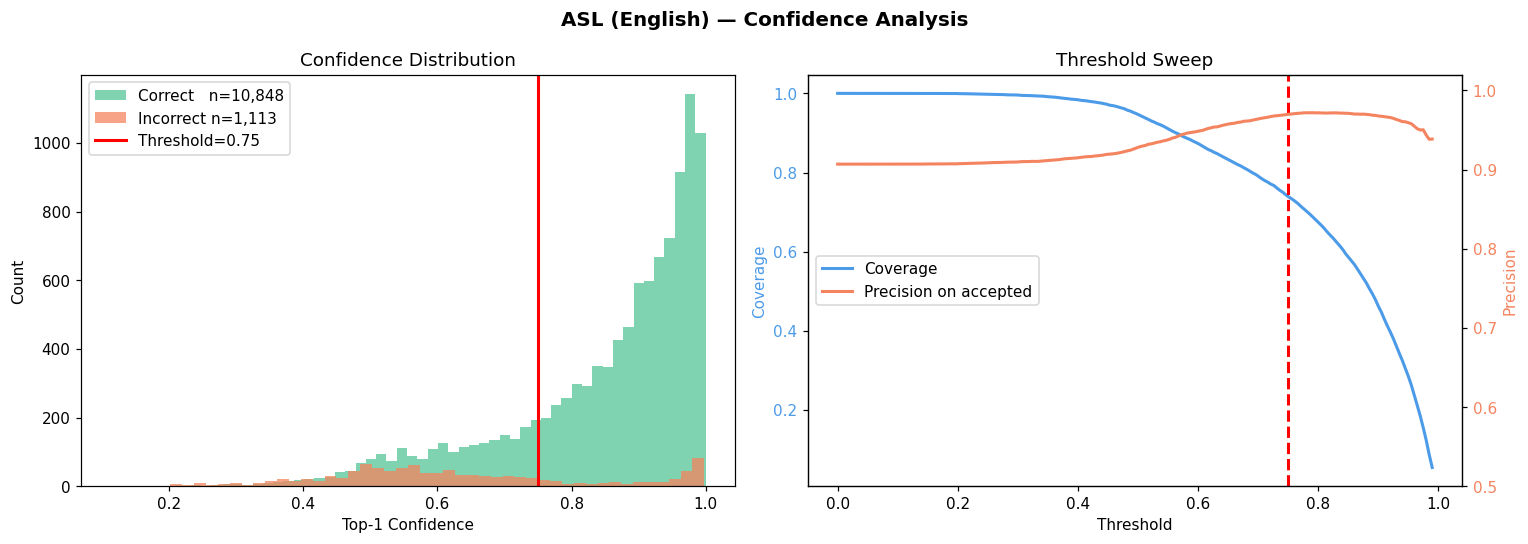

At threshold=0.75:
  Accepted : 73.9%  |  Precision on accepted: 96.99%
  Rejected : 26.1% — these show 'Low confidence' live

💡 Threshold for 90% coverage : 0.56  (precision=94.08%)


In [9]:
CURRENT_THRESHOLD = 0.75

correct_c   = y_conf[y_pred == y_test]
incorrect_c = y_conf[y_pred != y_test]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(correct_c,   bins=50, color="#56C596", alpha=0.75, label=f"Correct   n={len(correct_c):,}")
ax.hist(incorrect_c, bins=50, color="#F4845F", alpha=0.75, label=f"Incorrect n={len(incorrect_c):,}")
ax.axvline(CURRENT_THRESHOLD, color="red", lw=2, label=f"Threshold={CURRENT_THRESHOLD}")
ax.set_xlabel("Top-1 Confidence"); ax.set_ylabel("Count")
ax.set_title("Confidence Distribution"); ax.legend()

thresholds = np.linspace(0.0, 0.99, 200)
coverages  = []
precisions = []
for t in thresholds:
    mask = y_conf >= t
    coverages.append(mask.mean())
    precisions.append((y_pred[mask]==y_test[mask]).mean() if mask.sum()>0 else 1.0)

ax2 = axes[1]
ln1 = ax2.plot(thresholds, coverages,  color="#4C9BE8", lw=2, label="Coverage")
ax2.set_ylabel("Coverage", color="#4C9BE8"); ax2.tick_params(axis="y", labelcolor="#4C9BE8")
ax2b = ax2.twinx()
ln2 = ax2b.plot(thresholds, precisions, color="#F4845F", lw=2, label="Precision on accepted")
ax2b.set_ylabel("Precision", color="#F4845F"); ax2b.tick_params(axis="y", labelcolor="#F4845F")
ax2b.set_ylim(0.5, 1.02)
ax2.axvline(CURRENT_THRESHOLD, color="red", lw=2, linestyle="--")
ax2.set_xlabel("Threshold")
ax2.set_title("Threshold Sweep")
lines = ln1+ln2; ax2.legend(lines, [l.get_label() for l in lines], loc="center left")

plt.suptitle(f"{TITLE_PREFIX} — Confidence Analysis", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

mask = y_conf >= CURRENT_THRESHOLD
cov  = mask.mean()
prec = (y_pred[mask]==y_test[mask]).mean() if mask.sum()>0 else 0
print(f"At threshold={CURRENT_THRESHOLD}:")
print(f"  Accepted : {cov*100:.1f}%  |  Precision on accepted: {prec*100:.2f}%")
print(f"  Rejected : {(1-cov)*100:.1f}% — these show 'Low confidence' live\n")

idx90 = np.argmin(np.abs(np.array(coverages)-0.90))
print(f"💡 Threshold for 90% coverage : {thresholds[idx90]:.2f}  (precision={precisions[idx90]*100:.2f}%)")

## 8. Per-Class Confidence Box Plot

Sorted worst → best. Red = median below threshold. Classes with low/spread boxes will feel "shaky" live regardless of threshold.


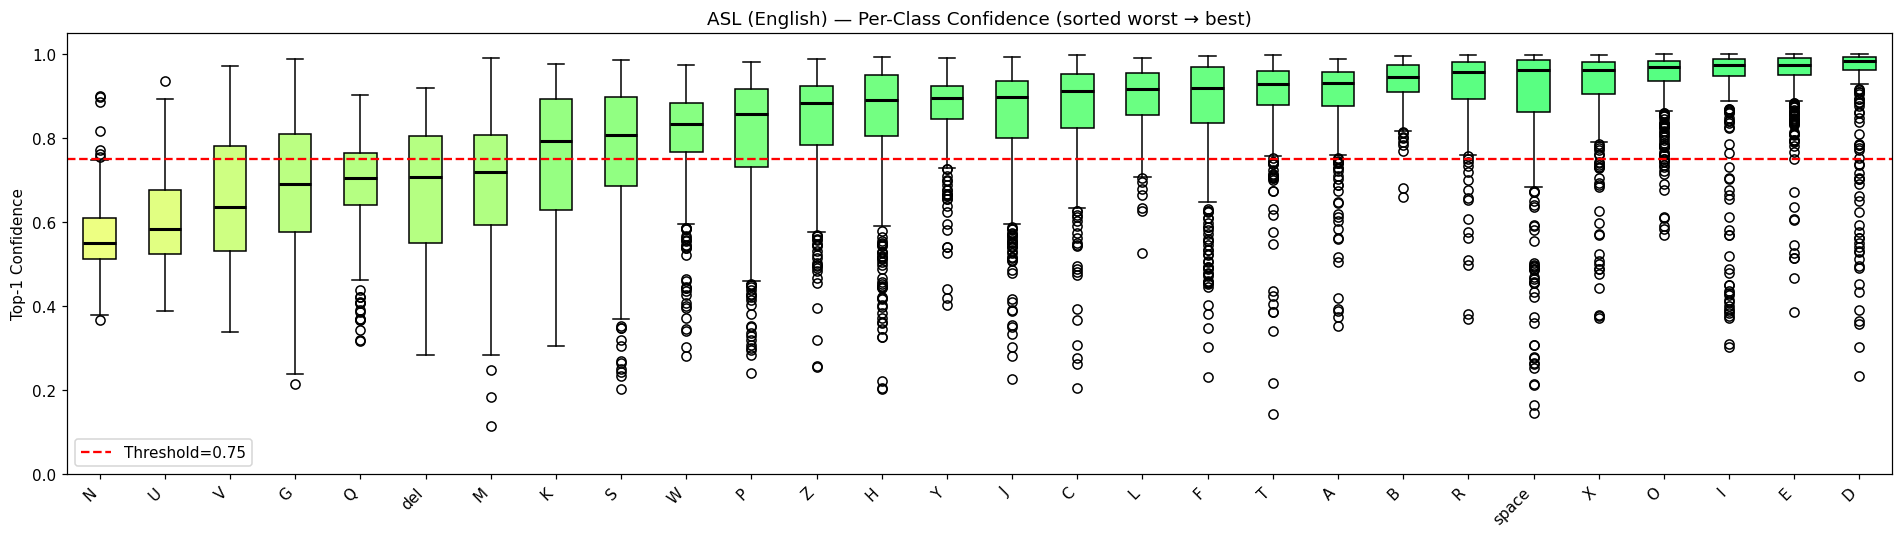

⚠ Classes with median confidence BELOW threshold:
  N       median=0.550
  U       median=0.583
  V       median=0.636
  G       median=0.690
  Q       median=0.705
  del     median=0.707
  M       median=0.719


In [10]:
conf_by_class = {lbl:[] for lbl in CLASS_LABELS}
for i, ti in enumerate(y_test):
    conf_by_class[CLASS_LABELS[ti]].append(y_conf[i])

medians = {k: np.median(v) for k,v in conf_by_class.items() if v}
sorted_labels = sorted(medians, key=medians.get)
data_sorted   = [conf_by_class[lbl] for lbl in sorted_labels]

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 5))
bp = ax.boxplot(data_sorted, patch_artist=True, notch=False,
                medianprops=dict(color="black", lw=2))
for patch, lbl in zip(bp["boxes"], sorted_labels):
    m = medians[lbl]
    patch.set_facecolor((max(0,min(1,2*(1-m))), max(0,min(1,2*m)), 0.3, 0.7))

ax.axhline(CURRENT_THRESHOLD, color="red", linestyle="--", lw=1.5,
           label=f"Threshold={CURRENT_THRESHOLD}")
ax.set_xticks(range(1,len(sorted_labels)+1))
ax.set_xticklabels(sorted_labels, rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylim(0, 1.05); ax.set_ylabel("Top-1 Confidence")
ax.set_title(f"{TITLE_PREFIX} — Per-Class Confidence (sorted worst → best)")
ax.legend(); plt.tight_layout(); plt.show()

weak = [(lbl, medians[lbl]) for lbl in sorted_labels if medians[lbl]<CURRENT_THRESHOLD]
if weak:
    print("⚠ Classes with median confidence BELOW threshold:")
    for lbl, m in weak:
        print(f"  {lbl:<6}  median={m:.3f}")
else:
    print("✓ All class medians above threshold.")
    print("  If live is still shaky → domain gap (lighting/angle), not model quality.")

## 9. Dataset Balance Check

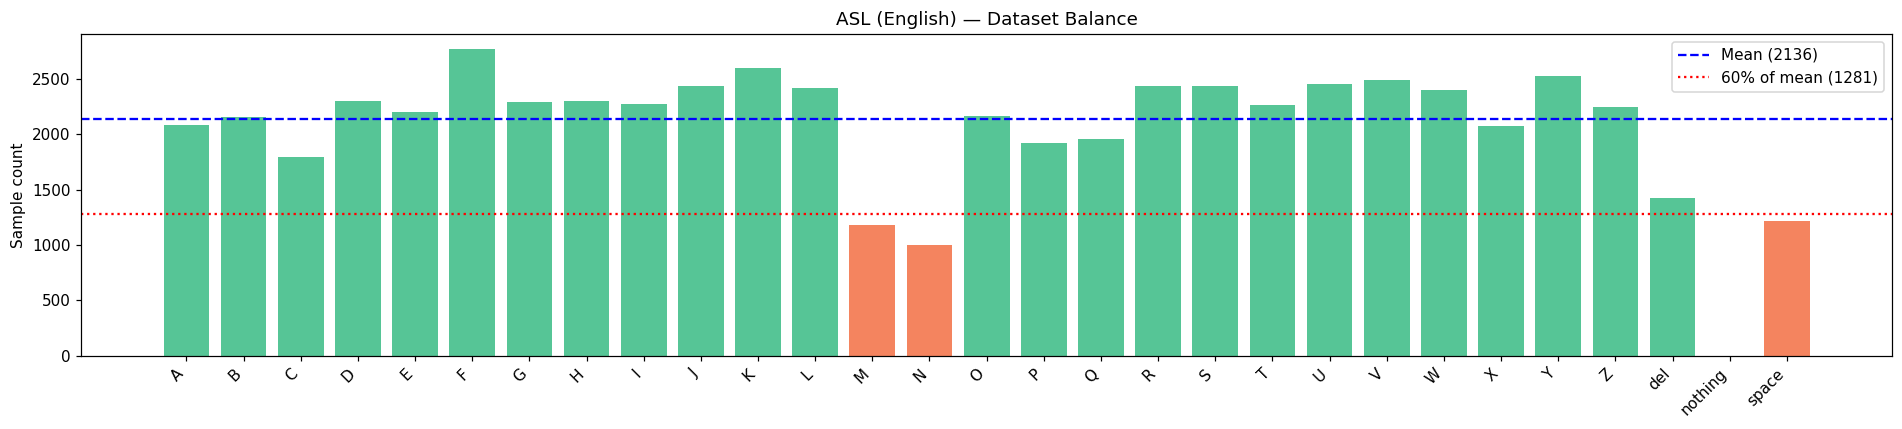

⚠ Under-represented classes:
  nothing  0 samples
  N       996 samples
  M       1,183 samples
  space   1,217 samples


In [11]:
label_counts  = df[label_col].value_counts()
avg_count     = label_counts.mean()
thresh_low    = avg_count * 0.60

fig, ax = plt.subplots(figsize=(max(14, len(CLASS_LABELS)*0.6), 4))
colors = ["#F4845F" if label_counts.get(l,0)<thresh_low else "#56C596" for l in CLASS_LABELS]
ax.bar(CLASS_LABELS, [label_counts.get(l,0) for l in CLASS_LABELS], color=colors)
ax.axhline(avg_count,  color="blue", linestyle="--", lw=1.5, label=f"Mean ({avg_count:.0f})")
ax.axhline(thresh_low, color="red",  linestyle=":",  lw=1.5, label=f"60% of mean ({thresh_low:.0f})")
plt.xticks(rotation=45 if len(CLASS_LABELS)>20 else 0, ha="right")
ax.set_ylabel("Sample count")
ax.set_title(f"{TITLE_PREFIX} — Dataset Balance")
ax.legend(); plt.tight_layout(); plt.show()

under = [(l, int(label_counts.get(l,0))) for l in CLASS_LABELS if label_counts.get(l,0)<thresh_low]
if under:
    print("⚠ Under-represented classes:")
    for l,c in sorted(under, key=lambda x:x[1]):
        print(f"  {l:<6}  {c:,} samples")
else:
    print("✓ Dataset is balanced.")

## 10. Automated Diagnosis Summary

Rule-based check across all metrics. Read top to bottom — fix CRITICAL issues first.


In [16]:
issues = []

# 1. Overall accuracy
if acc1 < 0.85:
    issues.append(("CRITICAL", f"Top-1 accuracy is {acc1*100:.1f}%. Model needs retraining or a larger architecture."))
elif acc1 < 0.92:
    issues.append(("WARNING",  f"Top-1 accuracy is {acc1*100:.1f}%. Fine-tuning on hard samples may help."))
else:
    issues.append(("OK",       f"Top-1 accuracy is {acc1*100:.1f}%. Model itself is not the bottleneck."))

# 2. Top-1 vs Top-2 gap
gap = acc2 - acc1
if gap > 0.06:
    confused = [f"{t}→{p}" for t,p,_ in pairs[:5]]
    issues.append(("WARNING", f"Top-2 gap = {gap*100:.1f}pp. Correct class is often 2nd. Main confused pairs: {', '.join(confused)}. Need targeted data or dynamic features for these."))
else:
    issues.append(("OK", f"Top-2 gap = {gap*100:.1f}pp. Model ranks the correct class confidently."))

# 3. Threshold coverage
mask = y_conf >= CURRENT_THRESHOLD; cov = mask.mean()
if cov < 0.70:
    issues.append(("CRITICAL", f"Threshold=0.75 accepts only {cov*100:.1f}% of predictions. Lower to {thresholds[idx90]:.2f} (90% coverage) or collect more varied training data."))
elif cov < 0.85:
    issues.append(("WARNING",  f"Threshold=0.75 accepts {cov*100:.1f}%. Some signs will feel unresponsive. Consider threshold={thresholds[idx90]:.2f}."))
else:
    issues.append(("OK",       f"Threshold accepts {cov*100:.1f}%. If live is still slow, check lighting/hand position (domain gap)."))

# 4. Per-class weak letters
wc = [l for l in CLASS_LABELS if per_class.loc[l,"f1-score"]<0.80]
if wc:
    issues.append(("WARNING", f"F1 < 0.80 for: {', '.join(wc)}. Collect more/better samples for these or check if they are inherently ambiguous with static keypoints."))
else:
    issues.append(("OK", "All classes have F1 >= 0.80."))

# 5. Dataset imbalance
if under:
    issues.append(("WARNING", f"Under-represented: {', '.join([l for l,_ in under])}. Augment or collect more samples."))
else:
    issues.append(("OK", "Dataset is balanced."))

# Print sorted by severity
order = {"CRITICAL":0,"WARNING":1,"OK":2}
icons = {"CRITICAL":"🔴","WARNING":"🟡","OK":"🟢"}
print("=" * 62)
print(f"  DIAGNOSIS SUMMARY — {TITLE_PREFIX}")
print("=" * 62)
for level, msg in sorted(issues, key=lambda x: order[x[0]]):
    print(f"\n{icons[level]} [{level}]  {msg}")
print("\n" + "=" * 62)

  DIAGNOSIS SUMMARY — ASL (English)

🟡 [WARNING]  Top-1 accuracy is 90.7%. Fine-tuning on hard samples may help.

🟡 [WARNING]  Top-2 gap = 8.2pp. Correct class is often 2nd. Main confused pairs: space→nothing, U→R, N→M, V→U, P→Q. Need targeted data or dynamic features for these.

🟡 [WARNING]  Threshold=0.75 accepts 73.9%. Some signs will feel unresponsive. Consider threshold=0.56.

🟡 [WARNING]  F1 < 0.80 for: M, N, R, U, nothing, space. Collect more/better samples for these or check if they are inherently ambiguous with static keypoints.

🟡 [WARNING]  Under-represented: M, N, nothing, space. Augment or collect more samples.



## 11. Live Diagnostics — Real-Time Probability Viewer

Runs the webcam + model and shows the **raw probability bar for every class** in real time.

**How to read it:**
- 🟢 Green bar = top-1 prediction
- 🔵 Cyan bar = above threshold but not top-1
- ⚫ Grey bar = below threshold
- Red vertical line = threshold

**Scenarios you can diagnose live:**
- Green bar is tall but doesn't cross the red line → lower the threshold
- Green bar is short and spread across many grey bars → model is uncertain; need more training data
- Green bar keeps switching between two classes → those two signs look too similar statically; need dynamic modelling
- Green bar is tall and crosses line but detection is slow → stabilisation window is too long

Controls: **q** = quit


In [17]:
class _ThrCam:
    def __init__(self, src=0):
        self.cap = cv2.VideoCapture(src)
        self.cap.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        self._q = queue.Queue(maxsize=1); self._ok = True
        self._t = threading.Thread(target=self._r, daemon=True); self._t.start()
    def _r(self):
        while self._ok:
            ret, f = self.cap.read()
            if ret:
                if not self._q.empty():
                    try: self._q.get_nowait()
                    except: pass
                self._q.put(f)
    def read(self): return self._q.get()
    def release(self):
        self._ok=False; self._t.join(timeout=2); self.cap.release()

_mph  = mp.solutions.hands
_mpd  = mp.solutions.drawing_utils
_hdet = _mph.Hands(static_image_mode=False, max_num_hands=1,
                    min_detection_confidence=0.70, min_tracking_confidence=0.65)

@tf.function(input_signature=[tf.TensorSpec(shape=[1,63], dtype=tf.float32)])
def _inf(x): return model(x, training=False)
_ = _inf(tf.zeros([1,63], dtype=tf.float32))

CAM_W, CAM_H = 640, 480
CHART_W = 380
WIN_W   = CAM_W + CHART_W
N       = len(CLASS_LABELS)
ROW_H   = max(10, CAM_H // N)
BAR_MAX = CHART_W - 90
DIAG_T  = 0.75

def run_live_diagnostics():
    cam = _ThrCam(src=0)
    cv2.namedWindow("SLR Live Diagnostics", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("SLR Live Diagnostics", WIN_W, CAM_H)
    print("🔍 Live diagnostics — q to quit")
    try:
        while True:
            frame = cam.read()
            frame = cv2.resize(frame, (CAM_W, CAM_H))
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            res = _hdet.process(rgb)
            rgb.flags.writeable = True
            plive = np.zeros(N, dtype=np.float32)
            top_lbl, top_cf = "No hand", 0.0
            if res.multi_hand_landmarks:
                _mpd.draw_landmarks(frame, res.multi_hand_landmarks[0], _mph.HAND_CONNECTIONS)
                lm = res.multi_hand_landmarks[0].landmark
                feat = np.array([[p.x,p.y,p.z] for p in lm], dtype=np.float32).reshape(1,-1)
                plive = _inf(tf.constant(feat))[0].numpy()
                ti = int(np.argmax(plive)); top_cf = float(plive[ti]); top_lbl = CLASS_LABELS[ti]

            # Chart panel
            panel = np.full((CAM_H, CHART_W, 3), 25, dtype=np.uint8)
            order = np.argsort(plive)[::-1]
            for rank, ci in enumerate(order):
                yt = rank * ROW_H; yb = yt + ROW_H - 2
                if yb >= CAM_H: break
                p = float(plive[ci])
                bw = int(p * BAR_MAX)
                clr = (80,220,100) if ci==order[0] else (60,200,230) if p>=DIAG_T else (70,70,70)
                cv2.rectangle(panel, (60, yt+1), (60+bw, yb), clr, -1)
                fs = max(0.27, min(0.42, ROW_H/25))
                cv2.putText(panel, CLASS_LABELS[ci], (2, yt+ROW_H-4),
                            cv2.FONT_HERSHEY_SIMPLEX, fs, (210,210,210), 1)
                cv2.putText(panel, f"{p*100:4.1f}%", (62+bw, yt+ROW_H-4),
                            cv2.FONT_HERSHEY_SIMPLEX, fs*0.85, (170,170,170), 1)

            tx = 60 + int(DIAG_T * BAR_MAX)
            cv2.line(panel, (tx,0), (tx,CAM_H), (0,60,220), 1)
            cv2.putText(panel, f"T={DIAG_T}", (tx+2, 11),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0,100,255), 1)

            # Status overlay on camera
            cv2.rectangle(frame, (0,0), (CAM_W,42), (30,30,30), -1)
            col = (0,255,0) if top_cf>=DIAG_T else (0,160,255) if top_cf>0 else (150,150,150)
            cv2.putText(frame, f"Top: {top_lbl}  {top_cf:.0%}",
                        (10,29), cv2.FONT_HERSHEY_SIMPLEX, 0.85, col, 2)

            cv2.imshow("SLR Live Diagnostics", np.hstack([frame, panel]))
            if cv2.waitKey(1) & 0xFF == ord("q"): break
    finally:
        cam.release(); cv2.destroyAllWindows()
        print("Closed.")

run_live_diagnostics()

AttributeError: module 'mediapipe' has no attribute 'solutions'